In [ ]:
# OASIS INFOBYTE

## DATA ANALYTICS - TASK 1

### Exploratory Data Analysis on Retail Sales Data

**Tools Used:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
df = pd.read_csv("Retail_Sales.csv")

df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [8]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(2000, 11)

Column Names:
['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']

Data Types:
transactions_id      int64
sale_date              str
sale_time              str
customer_id          int64
gender                 str
age                float64
category               str
quantiy            float64
price_per_unit     float64
cogs               float64
total_sale         float64
dtype: object

Missing Values:
transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64


In [9]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['transactions_id', 'customer_id', 'age', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']


In [10]:
# Mean
print("MEAN:")
print(df[numerical_columns].mean())

# Median
print("\nMEDIAN:")
print(df[numerical_columns].median())

# Mode
print("\nMODE:")
print(df[numerical_columns].mode().iloc[0])

# Standard Deviation
print("\nSTANDARD DEVIATION:")
print(df[numerical_columns].std())

MEAN:
transactions_id    1000.500000
customer_id          66.341500
age                  41.343216
quantiy               2.512769
price_per_unit      180.117677
cogs                 95.023886
total_sale          456.544817
dtype: float64

MEDIAN:
transactions_id    1000.5
customer_id          69.0
age                  42.0
quantiy               3.0
price_per_unit       50.0
cogs                 27.5
total_sale          150.0
dtype: float64

MODE:
transactions_id     1.0
customer_id         1.0
age                43.0
quantiy             4.0
price_per_unit     50.0
cogs               13.5
total_sale         50.0
Name: 0, dtype: float64

STANDARD DEVIATION:
transactions_id    577.494589
customer_id         44.937185
age                 13.668167
quantiy              1.132708
price_per_unit     189.685225
cogs               121.898695
total_sale         560.101381
dtype: float64


In [12]:
print(df.columns.tolist())

['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']


In [13]:
# Convert sale_date to datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])

# Check the date format
print("Data type:", df['sale_date'].dtype)
print("Start Date:", df['sale_date'].min())
print("End Date:", df['sale_date'].max())


Data type: datetime64[us]
Start Date: 2022-01-01 00:00:00
End Date: 2023-12-31 00:00:00


In [14]:
# Calculate monthly sales
monthly_sales = df.groupby(
    df['sale_date'].dt.to_period('M')
)['total_sale'].sum()

print(monthly_sales)

sale_date
2022-01    22635.0
2022-02    16110.0
2022-03    24505.0
2022-04    28705.0
2022-05    24980.0
2022-06    20700.0
2022-07    22195.0
2022-08    21195.0
2022-09    61770.0
2022-10    68235.0
2022-11    68915.0
2022-12    72880.0
2023-01    23790.0
2023-02    25170.0
2023-03    20530.0
2023-04    21925.0
2023-05    27010.0
2023-06    24555.0
2023-07    35925.0
2023-08    28270.0
2023-09    67560.0
2023-10    57880.0
2023-11    57135.0
2023-12    69145.0
Freq: M, Name: total_sale, dtype: float64


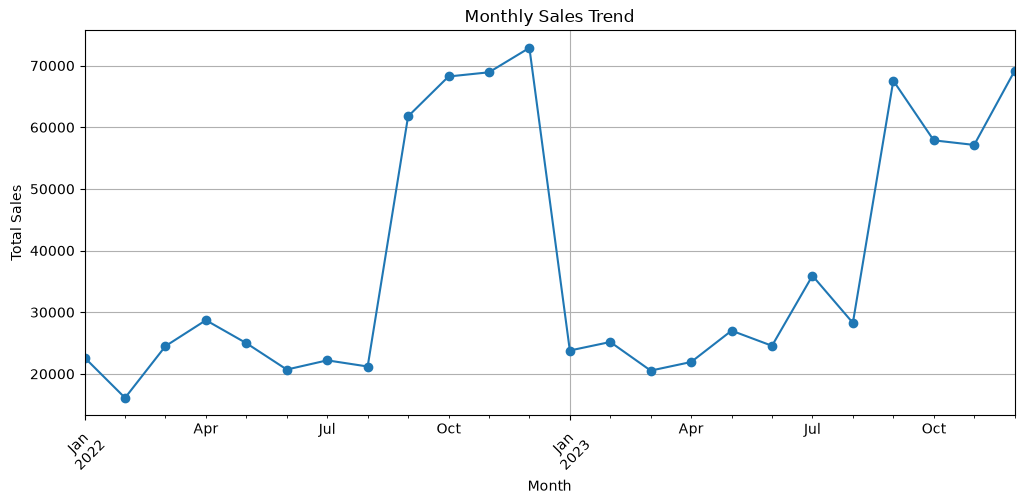

In [15]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()


In [ ]:
### Observation
The monthly sales trend shows how total sales changed over time.
The higher points indicate months with higher sales, while the lower
points indicate comparatively lower sales periods.

In [16]:
# Calculate quarterly sales
quarterly_sales = df.groupby(
    df['sale_date'].dt.to_period('Q')
)['total_sale'].sum()

print(quarterly_sales)

sale_date
2022Q1     63250.0
2022Q2     74385.0
2022Q3    105160.0
2022Q4    210030.0
2023Q1     69490.0
2023Q2     73490.0
2023Q3    131755.0
2023Q4    184160.0
Freq: Q-DEC, Name: total_sale, dtype: float64


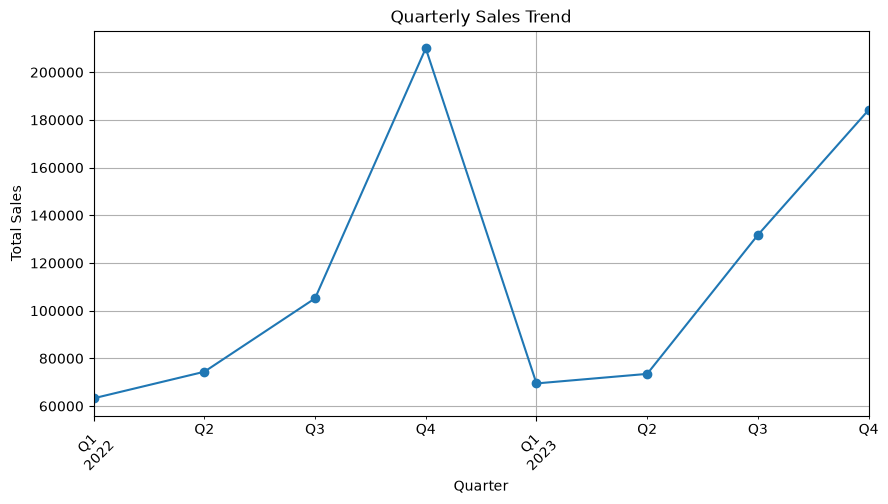

In [17]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
### Observation
The quarterly sales trend gives a broader view of sales performance.
It helps identify which quarters generated relatively higher or lower
sales and can help with future sales planning.

In [18]:
# Create age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False
)

print(df['age_group'].value_counts().sort_index())

age_group
Under 18      0
18-24       297
25-34       406
35-44       413
45-54       447
55-64       427
65+           0
Name: count, dtype: int64


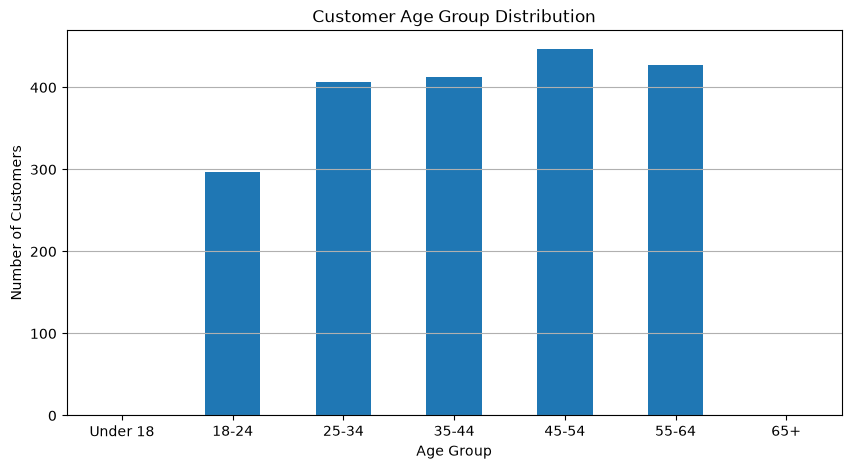

In [19]:
age_counts = df['age_group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

age_counts.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [ ]:
### Observation
The age-group distribution shows the customer segments represented in
the dataset. The largest age group represents the primary customer
segment and can be targeted with suitable products and marketing campaigns.

In [20]:
gender_counts = df['gender'].value_counts()

print(gender_counts)

gender
Female    1020
Male       980
Name: count, dtype: int64


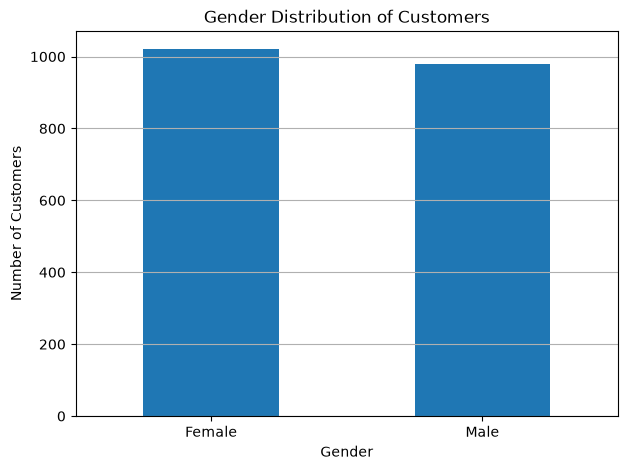

In [21]:
plt.figure(figsize=(7, 5))

gender_counts.plot(
    kind='bar',
    rot=0
)

plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.grid(axis='y')

plt.show()

In [ ]:
### Observation
The gender distribution shows the proportion of male and female
customers in the dataset. This information can help the business
understand its customer base and design targeted marketing strategies.
    

In [22]:
# Calculate total quantity sold by category
category_quantity = df.groupby('category')['quantiy'].sum().sort_values(ascending=False)

print(category_quantity)

category
Clothing       1785.0
Electronics    1698.0
Beauty         1535.0
Name: quantiy, dtype: float64


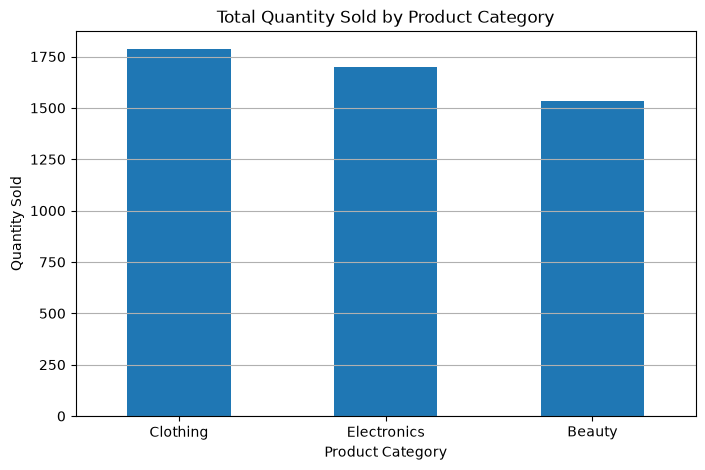

In [23]:
plt.figure(figsize=(8, 5))

category_quantity.plot(kind='bar')

plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [ ]:
### Observation
The chart compares the total quantity sold across product categories.
Categories with higher quantities represent stronger product demand
and may require better inventory planning to avoid stock shortages.
    

In [24]:
# Calculate revenue by product category
category_revenue = df.groupby('category')['total_sale'].sum().sort_values(
    ascending=False
)

print(category_revenue)


category
Electronics    313810.0
Clothing       311070.0
Beauty         286840.0
Name: total_sale, dtype: float64


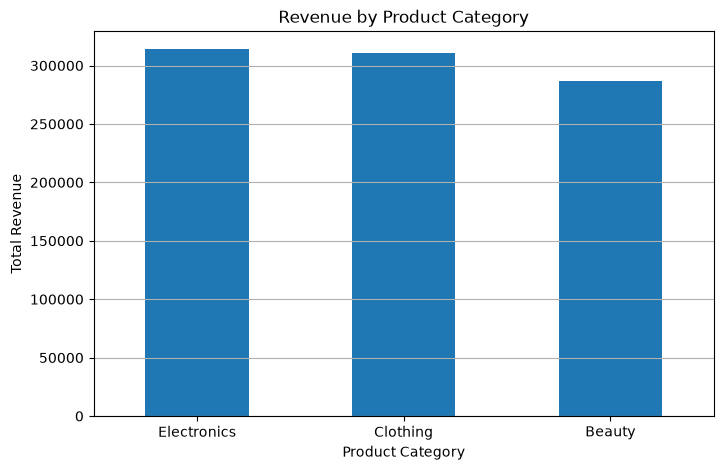

In [25]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [ ]:
### Observation
The revenue comparison shows which product categories contribute the
most to total sales. High-revenue categories should receive particular
attention in inventory management, promotions, and sales planning.

In [ ]:
### Dataset Limitation
The dataset contains product categories but does not contain a specific
product-name column. Therefore, a Top 10 individual products analysis
cannot be performed directly. Product category performance is analyzed
instead using quantity sold and total revenue.

In [26]:
# Select numerical columns
numeric_data = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

print(correlation_matrix)

                 transactions_id  customer_id       age   quantiy  \
transactions_id         1.000000     0.023845  0.033330 -0.013361   
customer_id             0.023845     1.000000 -0.002456  0.027665   
age                     0.033330    -0.002456  1.000000 -0.023642   
quantiy                -0.013361     0.027665 -0.023642  1.000000   
price_per_unit         -0.030674     0.009410 -0.042165  0.018397   
cogs                   -0.015848     0.067141 -0.034327  0.041463   
total_sale             -0.037738     0.017225 -0.061962  0.374721   

                 price_per_unit      cogs  total_sale  
transactions_id       -0.030674 -0.015848   -0.037738  
customer_id            0.009410  0.067141    0.017225  
age                   -0.042165 -0.034327   -0.061962  
quantiy                0.018397  0.041463    0.374721  
price_per_unit         1.000000  0.802198    0.851825  
cogs                   0.802198  1.000000    0.709780  
total_sale             0.851825  0.709780    1.000000  

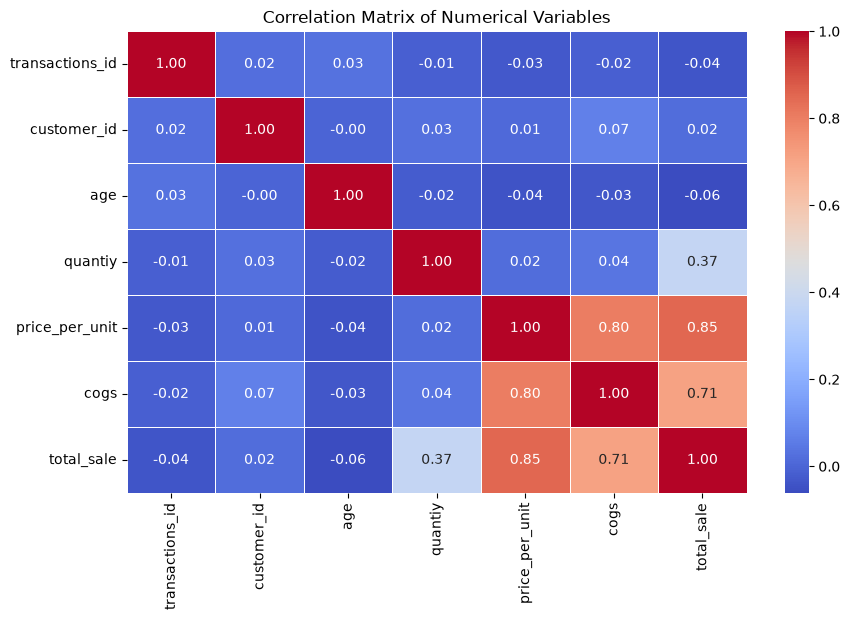

In [27]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

In [ ]:
### Observation
The correlation heatmap shows the relationship between numerical
variables in the dataset. Values closer to +1 indicate a strong
positive relationship, values closer to -1 indicate a strong negative
relationship, and values near 0 indicate a weak linear relationship.

In [28]:
# Calculate revenue by gender and category
gender_category_sales = df.groupby(
    ['gender', 'category']
)['total_sale'].sum().unstack()

print(gender_category_sales)

category    Beauty  Clothing  Electronics
gender                                   
Female    149470.0  162460.0     153470.0
Male      137370.0  148610.0     160340.0


<Figure size 1000x600 with 0 Axes>

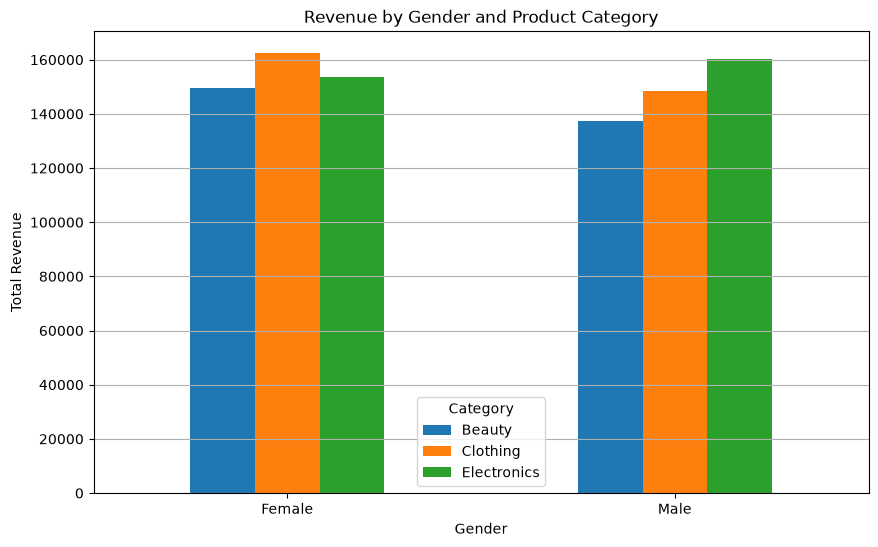

In [29]:
plt.figure(figsize=(10, 6))

gender_category_sales.plot(kind='bar', figsize=(10, 6))

plt.title('Revenue by Gender and Product Category')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.grid(axis='y')

plt.show()

In [ ]:
### Observation
The grouped bar chart compares revenue generated by different genders
across product categories. It helps identify whether certain product
categories perform differently across customer gender segments, which
can support more targeted marketing and product-promotion strategies.

In [30]:
# Key business insights

# 1. Best-selling category by quantity
best_quantity_category = category_quantity.idxmax()
best_quantity_value = category_quantity.max()

# 2. Highest revenue category
best_revenue_category = category_revenue.idxmax()
best_revenue_value = category_revenue.max()

# 3. Highest revenue month
best_month = monthly_sales.idxmax()
best_month_value = monthly_sales.max()

# 4. Largest customer age group
largest_age_group = age_counts.idxmax()
largest_age_group_value = age_counts.max()

# 5. Most common gender
most_common_gender = gender_counts.idxmax()
most_common_gender_value = gender_counts.max()

print("KEY BUSINESS INSIGHTS")
print("----------------------")

print(f"Best-selling category by quantity: {best_quantity_category}")
print(f"Quantity sold: {best_quantity_value}")

print(f"\nHighest revenue category: {best_revenue_category}")
print(f"Revenue: {best_revenue_value:.2f}")

print(f"\nHighest revenue month: {best_month}")
print(f"Revenue: {best_month_value:.2f}")

print(f"\nLargest customer age group: {largest_age_group}")
print(f"Number of customers: {largest_age_group_value}")

print(f"\nMost common gender: {most_common_gender}")
print(f"Number of customers: {most_common_gender_value}")

KEY BUSINESS INSIGHTS
----------------------
Best-selling category by quantity: Clothing
Quantity sold: 1785.0

Highest revenue category: Electronics
Revenue: 313810.00

Highest revenue month: 2022-12
Revenue: 72880.00

Largest customer age group: 45-54
Number of customers: 447

Most common gender: Female
Number of customers: 1020


In [31]:
# Overall sales summary

total_revenue = df['total_sale'].sum()
total_quantity = df['quantiy'].sum()
average_sale = df['total_sale'].mean()
total_transactions = df['transactions_id'].nunique()

print("OVERALL SALES SUMMARY")
print("---------------------")
print(f"Total Revenue: {total_revenue:.2f}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Average Transaction Value: {average_sale:.2f}")
print(f"Total Transactions: {total_transactions}")

OVERALL SALES SUMMARY
---------------------
Total Revenue: 911720.00
Total Quantity Sold: 5018.0
Average Transaction Value: 456.54
Total Transactions: 2000


In [ ]:
# Conclusion

The Exploratory Data Analysis of the retail sales dataset provided useful
insights into sales performance, customer demographics, and product
category behaviour.

## Key Findings

1. The analysis identified the highest-revenue product category and the
   category with the highest quantity sold.

2. Monthly and quarterly sales analysis helped identify periods of
   relatively higher and lower sales performance.

3. Customer age-group and gender analysis provided an understanding of
   the major customer segments.

4. The correlation heatmap showed relationships between numerical
   variables such as quantity, price, cost, and total sales.

## Actionable Business Recommendations

### 1. Focus on High-Revenue Categories
The business should prioritize high-revenue product categories through
better inventory availability, promotions, and targeted sales campaigns.

### 2. Improve Seasonal Sales Planning
Monthly and quarterly sales trends should be used to prepare inventory
and promotional campaigns before high-demand periods.

### 3. Target Major Customer Segments
The largest age group and customer gender segments can be targeted with
personalized offers, advertisements, and product recommendations.

### 4. Optimize Inventory
Categories with high quantities sold should be monitored carefully to
avoid stock shortages and maintain product availability.

### 5. Use Data-Driven Marketing
The relationship between customer demographics and category sales can be
used to create more targeted marketing strategies.

In [ ]:
## Overall Sales Findings

The retail dataset contains **2,000 transactions** with a total revenue of **₹911,720**. The total quantity of products sold was **5,018 units**, with an average transaction value of approximately **₹456.54**.

These results indicate that the dataset represents a substantial number of customer transactions and provides a useful basis for understanding sales performance, customer behaviour, and product-category demand.
